# 3 . Ejercicio bermuda: Longstaff-Schwartz

Un put bermuda (fechas de ejercicio discretas) se construye con
`q.exercise(id, dates, exercise_value, continuation)` -- el motor resuelve la politica optima
de ejercicio via regresion de Longstaff-Schwartz sobre las trayectorias Monte Carlo simuladas
bajo `GBM`, y la medida `PayoffExerciseQ` devuelve el precio junto con diagnosticos por fecha
de decision (`.times`=fechas, `.primary`=fraccion de trayectorias ejercidas en esa fecha,
`.secondary`=valor de continuacion condicional). Este notebook visualiza esos diagnosticos y
compara el precio bermuda contra la cota inferior teorica -- el precio europeo equivalente --
y contra su limite cuando el numero de fechas de ejercicio crece (aproximacion al americano).


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

import engine
import engine_typed as q
from engine_typed import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. Mercado y plantillas de contrato


In [2]:
S0, K, R, Q_DIV, SIGMA, T = 100.0, 100.0, 0.04, 0.0, 0.30, 1.0
OBS = "EQ.SPOT.IDX"

eng = engine.Engine()
model = eng.create_model("GBM", {"s0": S0, "r": R, "q": Q_DIV, "sigma": SIGMA, "observable": OBS})
market = engine.MarketSnapshot(pillars=[T], zero_rates=[R])
execution = engine.ExecutionContext({"backend": "cpu"})
pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 100_000.0, "n_steps": 1.0, "seed": 41.0})


def european_put_contract(strike):
    return q.when(T, q.cashflow("USD", q.maximum(strike - q.fixing(OBS, T), 0.0)))


def bermudan_put_contract(strike, exercise_dates):
    exercise_value = q.maximum(strike - q.current(OBS), 0.0)
    continuation = european_put_contract(strike)
    return q.exercise("EX", exercise_dates, exercise_value, continuation)


def price_european_put(strike):
    product = eng.create_product("Payoff", q.PayoffProduct(id="EU", contract=european_put_contract(strike)).to_params())
    return eng.price(product, ["PayoffPriceQ"], model, market, pricing, execution)["PayoffPriceQ"].scalar


def price_bermudan_put(strike, exercise_dates):
    product = eng.create_product("Payoff", q.PayoffProduct(id="BM", contract=bermudan_put_contract(strike, exercise_dates)).to_params())
    return eng.price(product, ["PayoffExerciseQ"], model, market, pricing, execution)["PayoffExerciseQ"]


print(f"S0={S0}  K={K}  sigma={SIGMA:.0%}  T={T}y")


S0=100.0  K=100.0  sigma=30%  T=1.0y


## 2. Put bermuda vs put europea (misma cesta de parametros)


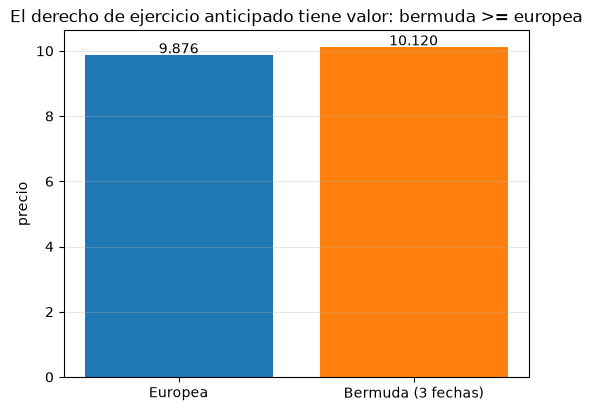

europea=9.8758  bermuda=10.1203  prima de ejercicio anticipado=0.2444


In [3]:
EXERCISE_DATES = [0.25, 0.5, 0.75]

european_price = price_european_put(K)
bermudan_result = price_bermudan_put(K, EXERCISE_DATES)
bermudan_price = bermudan_result.scalar

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Europea", "Bermuda (3 fechas)"], [european_price, bermudan_price], color=["tab:blue", "tab:orange"])
for i, v in enumerate([european_price, bermudan_price]):
    ax.text(i, v + 0.05, f"{v:.3f}", ha="center")
ax.set_ylabel("precio")
ax.set_title("El derecho de ejercicio anticipado tiene valor: bermuda >= europea")
ax.grid(alpha=0.3, axis="y")
plt.show()

print(f"europea={european_price:.4f}  bermuda={bermudan_price:.4f}  prima de ejercicio anticipado={bermudan_price - european_price:.4f}")


## 3. Diagnosticos de ejercicio por fecha de decision

`PayoffExerciseQ.primary` es la fraccion de trayectorias que, en cada fecha de decision,
la politica de Longstaff-Schwartz decide ejercer (en vez de continuar) -- `.secondary` es el
valor de continuacion condicional medio en esa fecha.


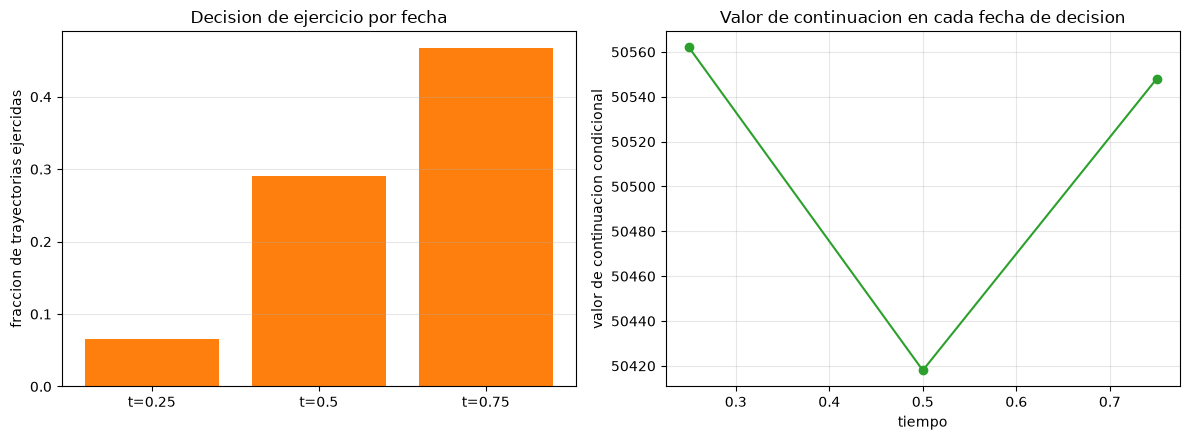

t=0.25  ejercida=6.5%  continuacion=50,562.0
t=0.50  ejercida=29.0%  continuacion=50,418.0
t=0.75  ejercida=46.7%  continuacion=50,548.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([f"t={t}" for t in bermudan_result.times], bermudan_result.primary, color="tab:orange")
axes[0].set_ylabel("fraccion de trayectorias ejercidas")
axes[0].set_title("Decision de ejercicio por fecha")
axes[0].grid(alpha=0.3, axis="y")

axes[1].plot(bermudan_result.times, bermudan_result.secondary, "o-", color="tab:green")
axes[1].set_ylabel("valor de continuacion condicional")
axes[1].set_xlabel("tiempo")
axes[1].set_title("Valor de continuacion en cada fecha de decision")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t, frac, cont in zip(bermudan_result.times, bermudan_result.primary, bermudan_result.secondary):
    print(f"t={t:.2f}  ejercida={frac:.1%}  continuacion={cont:,.1f}")


## 4. Prima de ejercicio anticipado frente a moneyness


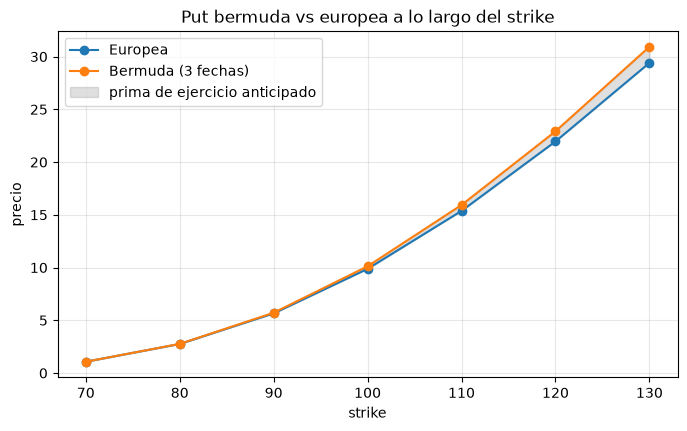

In [5]:
strikes = np.arange(70.0, 131.0, 10.0)
european_curve, bermudan_curve = [], []
for k in strikes:
    european_curve.append(price_european_put(float(k)))
    bermudan_curve.append(price_bermudan_put(float(k), EXERCISE_DATES).scalar)

european_curve = np.array(european_curve)
bermudan_curve = np.array(bermudan_curve)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strikes, european_curve, "o-", label="Europea")
ax.plot(strikes, bermudan_curve, "o-", label="Bermuda (3 fechas)")
ax.fill_between(strikes, european_curve, bermudan_curve, color="grey", alpha=0.25, label="prima de ejercicio anticipado")
ax.set_xlabel("strike")
ax.set_ylabel("precio")
ax.set_title("Put bermuda vs europea a lo largo del strike")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 5. Convergencia hacia el limite americano

Cuantas mas fechas de ejercicio se permiten, mas se acerca el precio bermuda al limite
americano (ejercicio continuo). El ruido Monte Carlo de la regresion de Longstaff-Schwartz es
visible en la curva -- coherente con que cada punto es una regresion independiente sobre un
numero finito de trayectorias, no una formula cerrada.


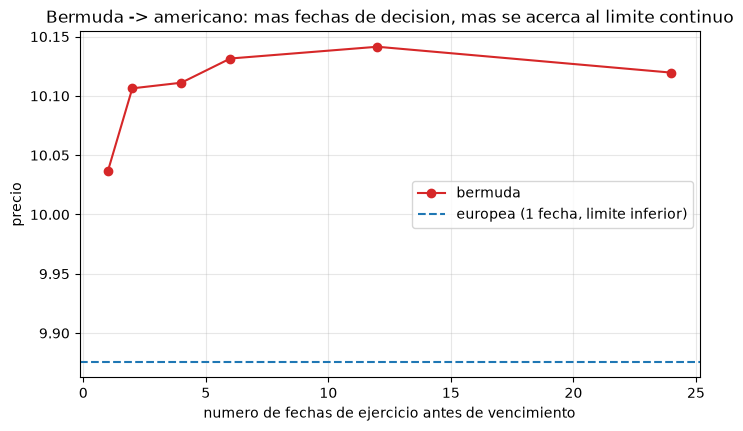

In [6]:
n_dates_grid = [1, 2, 4, 6, 12, 24]
convergence_prices = []
for n in n_dates_grid:
    dates = list(np.linspace(T / (n + 1), T, n + 1))[:-1]
    convergence_prices.append(price_bermudan_put(K, dates).scalar)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_dates_grid, convergence_prices, "o-", color="tab:red", label="bermuda")
ax.axhline(european_price, color="tab:blue", linestyle="--", label="europea (1 fecha, limite inferior)")
ax.set_xlabel("numero de fechas de ejercicio antes de vencimiento")
ax.set_ylabel("precio")
ax.set_title("Bermuda -> americano: mas fechas de decision, mas se acerca al limite continuo")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
